**In this notebook**
ML Dataset Preparation
   ->
Train/Test split
   ->
Preprocessing
   ->
Linear Regression
   ->
Random Forest
   ->
XGBoost
   ->
R² / MAE / RMSE / MAPE
   ->
Model comparison
   ->
Best model

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/revive_pay_model_data.csv")

print("Dataset shape:", df.shape)

Dataset shape: (99441, 30)


In [3]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_payment_value,payment_count,...,purchase_year,purchase_month,purchase_day,purchase_dayofweek,purchase_hour,approval_delay_hours,delivery_time_days,estimated_delivery_gap_days,recovery_opportunity,revenue_at_risk
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71,3.0,...,2017,10,2,0,10,0.178333,8.436574,15.544063,0,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46,1.0,...,2018,7,24,1,20,30.713889,13.782037,19.137766,0,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12,1.0,...,2018,8,8,2,8,0.276111,9.394213,26.639711,0,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20,1.0,...,2017,11,18,5,19,0.298056,13.208750,26.188819,0,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62,1.0,...,2018,2,13,1,21,1.030556,2.873877,12.112049,0,0.0


## 1. Define Features and Target

The objective is to predict whether an order represents a historical recovery opportunity.

- Target: recovery_opportunity
- Exclude identifiers and raw timestamps
- Exclude revenue_at_risk to prevent target leakage
- Exclude order_status if it was used to derive the recovery target

In [4]:
# Target
target = "recovery_opportunity"

# Columns that should not be used as ML features
drop_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "revenue_at_risk",
    "recovery_opportunity",
    "order_status"
]

X = df.drop(columns=drop_columns)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (99441, 19)
Target shape: (99441,)

Target distribution:
recovery_opportunity
0    98210
1     1231
Name: count, dtype: int64

Features:
['total_payment_value', 'payment_count', 'payment_installments', 'primary_payment_type', 'item_count', 'total_item_price', 'total_freight_value', 'unique_products', 'unique_sellers', 'customer_city', 'customer_state', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_dayofweek', 'purchase_hour', 'approval_delay_hours', 'delivery_time_days', 'estimated_delivery_gap_days']


In [5]:
print("Number of features:", X.shape[1])
print("\nFeature data types:")
print(X.dtypes)

Number of features: 19

Feature data types:
total_payment_value            float64
payment_count                  float64
payment_installments           float64
primary_payment_type               str
item_count                     float64
total_item_price               float64
total_freight_value            float64
unique_products                float64
unique_sellers                 float64
customer_city                      str
customer_state                     str
purchase_year                    int64
purchase_month                   int64
purchase_day                     int64
purchase_dayofweek               int64
purchase_hour                    int64
approval_delay_hours           float64
delivery_time_days             float64
estimated_delivery_gap_days    float64
dtype: object


In [6]:
print("\nMissing values:")
print(X.isnull().sum().sort_values(ascending=False).head(20))


Missing values:
delivery_time_days             2965
item_count                      775
total_freight_value             775
unique_sellers                  775
unique_products                 775
total_item_price                775
approval_delay_hours            160
payment_installments              1
payment_count                     1
total_payment_value               1
primary_payment_type              1
customer_state                    0
customer_city                     0
purchase_year                     0
purchase_month                    0
purchase_dayofweek                0
purchase_day                      0
purchase_hour                     0
estimated_delivery_gap_days       0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (79552, 19)
Testing set: (19889, 19)


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "primary_payment_type",
    "customer_city",
    "customer_state"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 3
Numerical features: 16


In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 2. Baseline Model — Logistic Regression

Logistic Regression is used as a simple baseline for the binary recovery-opportunity classification problem.

In [10]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 3. Random Forest

Random Forest is used to capture nonlinear relationships between order characteristics and recovery opportunities.

In [11]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 4. XGBoost

XGBoost is used as the final gradient-boosting model to capture complex nonlinear relationships and interactions between order features.

In [12]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


## 5. Model Evaluation

All three models are evaluated on the same unseen test set using precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [13]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.0179,0.4146,0.0343,0.6209,0.1045
1,Random Forest,0.6168,0.8049,0.6984,0.9914,0.8336
2,XGBoost,0.8929,0.7114,0.7919,0.9981,0.9018


## 6. XGBoost Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified recovery opportunities.

Confusion Matrix:
[[19622    21]
 [   71   175]]


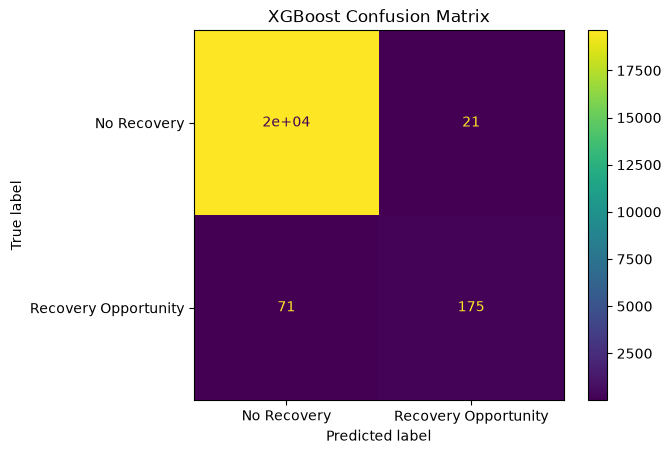

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_xgb = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Recovery", "Recovery Opportunity"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

## 7. Feature Importance

Feature importance is used to identify which features contribute most to the XGBoost model's recovery-opportunity predictions.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the fitted XGBoost model
xgb_classifier = xgb_model.named_steps["model"]

# Get transformed feature names
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = xgb_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
14,num__delivery_time_days,0.646624
5,num__total_freight_value,0.064068
3889,cat__customer_state_PA,0.015095
4,num__total_item_price,0.012233
3,num__item_count,0.009504
8,num__purchase_year,0.009110
9,num__purchase_month,0.008400
6,num__unique_products,0.008009
3901,cat__customer_state_SP,0.008007
2446,cat__customer_city_osasco,0.007704


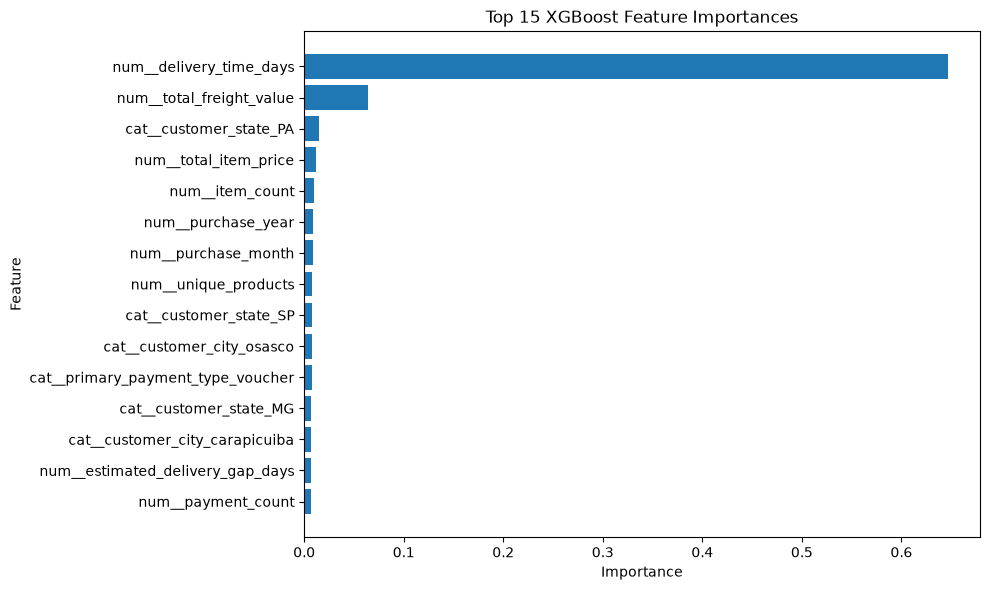

In [16]:
top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

## 8. XGBoost Hyperparameter Tuning

The baseline XGBoost model performed best among the evaluated models.
Hyperparameter tuning is used to find a better combination of model parameters and improve predictive performance while controlling overfitting.

In [17]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_tuning = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

print("XGBoost tuning pipeline created successfully.")

XGBoost tuning pipeline created successfully.


In [18]:
param_grid = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
}

In [19]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=xgb_tuning,
    param_grid=param_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV PR-AUC:")
print(grid_search.best_score_)

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters:
{'model__colsample_bytree': 0.7, 'model__learning_rate': 0.03, 'model__max_depth': 8, 'model__n_estimators': 200, 'model__subsample': 1.0}

Best CV PR-AUC:
0.8715454379331228


In [20]:
# Best tuned model
tuned_model = grid_search.best_estimator_

# Predictions on the same test set
y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Test Results")
print("--------------------------")
print("Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("Recall:", round(recall_score(y_test, y_pred_tuned), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_tuned), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_tuned), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_tuned), 4))

Tuned XGBoost Test Results
--------------------------
Precision: 0.9441
Recall: 0.687
F1-Score: 0.7953
ROC-AUC: 0.9981
PR-AUC: 0.8982


## Graphs 

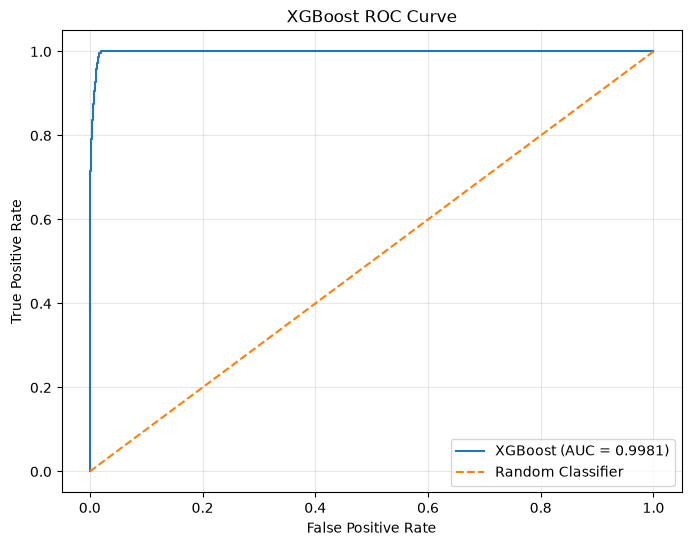

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)
roc_auc = roc_auc_score(y_test, y_prob_tuned)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

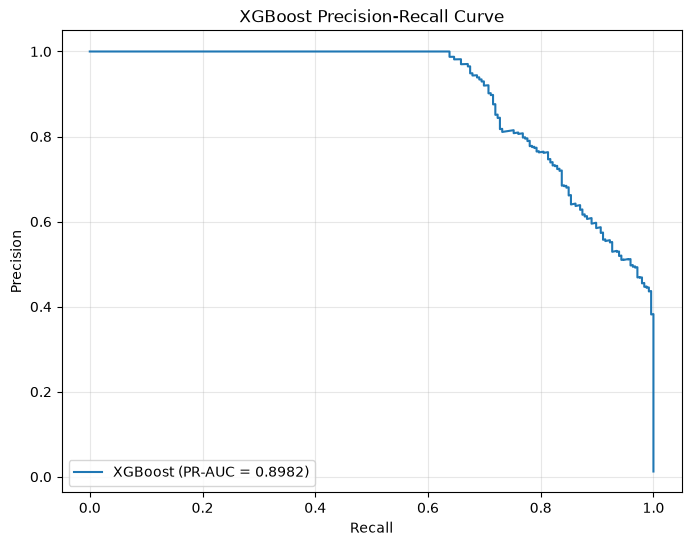

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_tuned
)

pr_auc = average_precision_score(y_test, y_prob_tuned)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (PR-AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

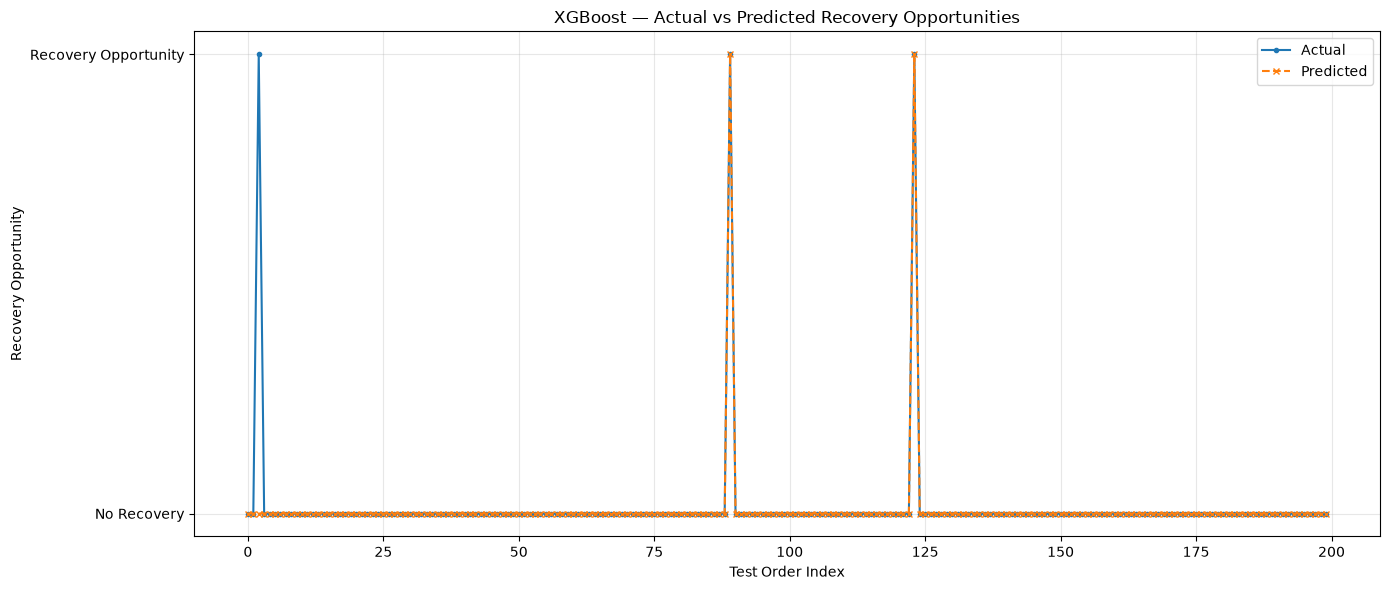

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Take first 200 test observations for clear visualization
n = 200

actual = np.array(y_test)[:n]
predicted = np.array(y_pred_tuned)[:n]

plt.figure(figsize=(14, 6))

plt.plot(
    range(n),
    actual,
    label="Actual",
    marker="o",
    linestyle="-",
    markersize=3
)

plt.plot(
    range(n),
    predicted,
    label="Predicted",
    marker="x",
    linestyle="--",
    markersize=4
)

plt.yticks([0, 1], ["No Recovery", "Recovery Opportunity"])

plt.xlabel("Test Order Index")
plt.ylabel("Recovery Opportunity")
plt.title("XGBoost — Actual vs Predicted Recovery Opportunities")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

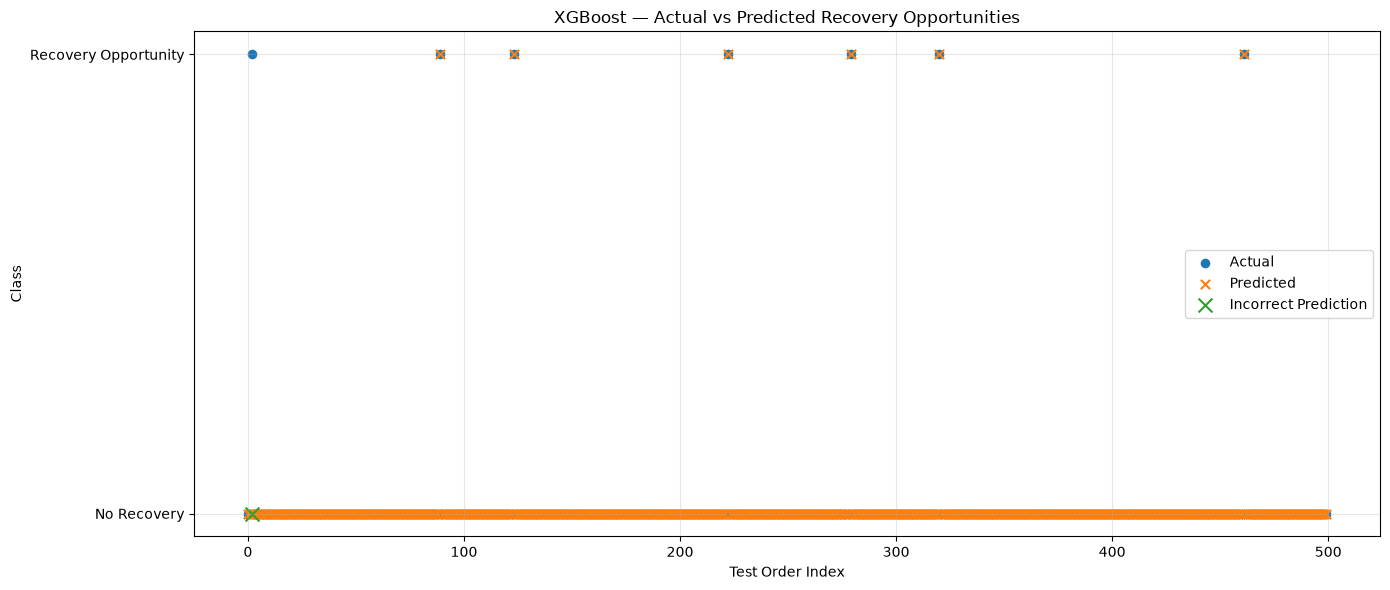

In [24]:
import numpy as np
import matplotlib.pyplot as plt

n = 500

actual = np.array(y_test)[:n]
predicted = np.array(y_pred_tuned)[:n]

# Correct predictions
correct = actual == predicted

plt.figure(figsize=(14, 6))

# Actual values
plt.scatter(
    range(n),
    actual,
    label="Actual",
    marker="o",
    s=35
)

# Predicted values
plt.scatter(
    range(n),
    predicted,
    label="Predicted",
    marker="x",
    s=45
)

# Highlight incorrect predictions
wrong_idx = np.where(~correct)[0]

plt.scatter(
    wrong_idx,
    predicted[wrong_idx],
    marker="x",
    s=100,
    label="Incorrect Prediction"
)

plt.yticks(
    [0, 1],
    ["No Recovery", "Recovery Opportunity"]
)

plt.xlabel("Test Order Index")
plt.ylabel("Class")
plt.title("XGBoost — Actual vs Predicted Recovery Opportunities")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Saved the tuned model

In [25]:
import joblib

# Save the complete tuned pipeline
joblib.dump(tuned_model, "../src/tuned_xgb_model.pkl")

print("Tuned XGBoost model saved successfully.")

Tuned XGBoost model saved successfully.


In [26]:
import joblib

# Load the saved model
loaded_model = joblib.load("../src/tuned_xgb_model.pkl")

print("Tuned model loaded successfully.")

Tuned model loaded successfully.


In [30]:
# Test the loaded model
y_pred_loaded = loaded_model.predict(X_test)

print("Prediction successful!")
print("Number of predictions:", len(y_pred_loaded))
print("First 20 predictions:", y_pred_loaded[:20])

Prediction successful!
Number of predictions: 19889
First 20 predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Finding JSON for recovery

In [35]:
# Get one actual recovery opportunity case
positive_case = X_test[y_test == 1].iloc[0]

print("One actual Recovery Opportunity case:")
print(positive_case)

One actual Recovery Opportunity case:
total_payment_value                 117.04
payment_count                          1.0
payment_installments                   6.0
primary_payment_type           credit_card
item_count                             1.0
total_item_price                      99.9
total_freight_value                  17.14
unique_products                        1.0
unique_sellers                         1.0
customer_city                    itaberaba
customer_state                          BA
purchase_year                         2018
purchase_month                           1
purchase_day                            27
purchase_dayofweek                       5
purchase_hour                           11
approval_delay_hours              0.227778
delivery_time_days                     NaN
estimated_delivery_gap_days      29.527199
Name: 29564, dtype: object


In [36]:
import json

positive_case = X_test[y_test == 1].iloc[0]

api_input = positive_case.to_dict()

print(json.dumps(api_input, indent=4, default=str))

{
    "total_payment_value": 117.04,
    "payment_count": 1.0,
    "payment_installments": 6.0,
    "primary_payment_type": "credit_card",
    "item_count": 1.0,
    "total_item_price": 99.9,
    "total_freight_value": 17.14,
    "unique_products": 1.0,
    "unique_sellers": 1.0,
    "customer_city": "itaberaba",
    "customer_state": "BA",
    "purchase_year": 2018,
    "purchase_month": 1,
    "purchase_day": 27,
    "purchase_dayofweek": 5,
    "purchase_hour": 11,
    "approval_delay_hours": 0.2277777777777777,
    "delivery_time_days": NaN,
    "estimated_delivery_gap_days": 29.527199074074076
}


In [37]:
positive_cases = X_test[
    (y_test == 1) &
    (X_test["delivery_time_days"].notna())
]

positive_case = positive_cases.iloc[0]

import json
print(json.dumps(positive_case.to_dict(), indent=4, default=str))

{
    "total_payment_value": 153.51,
    "payment_count": 1.0,
    "payment_installments": 3.0,
    "primary_payment_type": "credit_card",
    "item_count": 1.0,
    "total_item_price": 135.0,
    "total_freight_value": 18.51,
    "unique_products": 1.0,
    "unique_sellers": 1.0,
    "customer_city": "florianopolis",
    "customer_state": "SC",
    "purchase_year": 2016,
    "purchase_month": 10,
    "purchase_day": 9,
    "purchase_dayofweek": 6,
    "purchase_hour": 15,
    "approval_delay_hours": 19.014722222222225,
    "delivery_time_days": 30.96798611111111,
    "estimated_delivery_gap_days": 59.34726851851852
}


In [55]:
# Find actual recovery cases
positive_cases = X_test[y_test == 1]

print("Number of actual recovery cases:", len(positive_cases))

# Take the first recovery case
positive_case = positive_cases.iloc[0]

# Get its original index
case_index = positive_case.name

print("Actual label:", y_test.loc[case_index])

# Convert to API JSON
api_input = positive_case.to_dict()

import json
print(json.dumps(api_input, indent=4, default=str))

Number of actual recovery cases: 246
Actual label: 1
{
    "total_payment_value": 117.04,
    "payment_count": 1.0,
    "payment_installments": 6.0,
    "primary_payment_type": "credit_card",
    "item_count": 1.0,
    "total_item_price": 99.9,
    "total_freight_value": 17.14,
    "unique_products": 1.0,
    "unique_sellers": 1.0,
    "customer_city": "itaberaba",
    "customer_state": "BA",
    "purchase_year": 2018,
    "purchase_month": 1,
    "purchase_day": 27,
    "purchase_dayofweek": 5,
    "purchase_hour": 11,
    "approval_delay_hours": 0.2277777777777777,
    "delivery_time_days": NaN,
    "estimated_delivery_gap_days": 29.527199074074076
}


In [56]:
# Check what the tuned model predicts for this actual recovery case

positive_probability = tuned_model.predict_proba(
    positive_case.to_frame().T
)[:, 1][0]

positive_prediction = tuned_model.predict(
    positive_case.to_frame().T
)[0]

print("Actual label:", y_test.loc[case_index])
print("Model probability:", positive_probability)
print("Model prediction at 0.5 threshold:", positive_prediction)

Actual label: 1
Model probability: 0.09413103
Model prediction at 0.5 threshold: 0


In [59]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

positive_probs = y_prob_tuned[y_test == 1]

for threshold in thresholds:
    detected = (positive_probs >= threshold).sum()
    missed = (positive_probs < threshold).sum()
    
    print(
        f"Threshold {threshold}: "
        f"Detected = {detected}, "
        f"Missed = {missed}, "
        f"Recall = {detected / len(positive_probs):.4f}"
    )

Threshold 0.5: Detected = 169, Missed = 77, Recall = 0.6870
Threshold 0.4: Detected = 177, Missed = 69, Recall = 0.7195
Threshold 0.3: Detected = 192, Missed = 54, Recall = 0.7805
Threshold 0.2: Detected = 208, Missed = 38, Recall = 0.8455
Threshold 0.1: Detected = 228, Missed = 18, Recall = 0.9268


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_tuned >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.5,0.9441,0.6870,0.7953
1,0.4,0.8676,0.7195,0.7867
2,0.3,0.7837,0.7805,0.7821
3,0.2,0.6797,0.8455,0.7536
4,0.1,0.5403,0.9268,0.6826


Confusion Matrix at Threshold 0.20:
[[19616    27]
 [   69   177]]


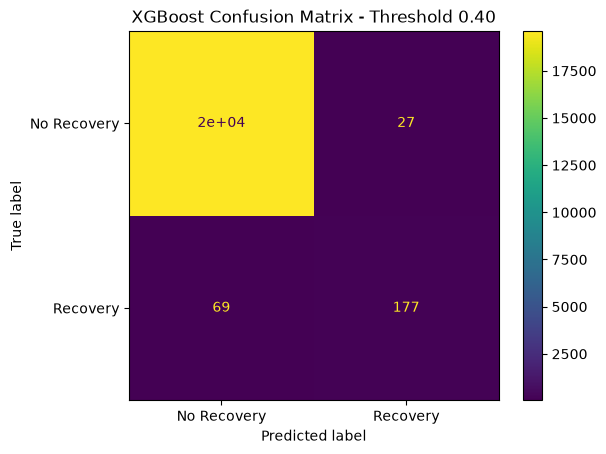

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

threshold = 0.40

y_pred_02 = (y_prob_tuned >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_02)

print("Confusion Matrix at Threshold 0.20:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Recovery", "Recovery"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix - Threshold 0.40")
plt.show()

## Recall Model

In [46]:
# Probabilities for all actual recovery opportunities
positive_probs = y_prob_tuned[y_test == 1]

print("Number of actual positive cases:", len(positive_probs))
print("Minimum probability:", positive_probs.min())
print("Maximum probability:", positive_probs.max())
print("Mean probability:", positive_probs.mean())

print("\nProbability percentiles:")
print(np.percentile(positive_probs, [10, 25, 50, 75, 90]))

Number of actual positive cases: 246
Minimum probability: 0.0031342085
Maximum probability: 0.98901635
Mean probability: 0.71911126

Probability percentiles:
[0.13120352 0.33783834 0.96995607 0.98009278 0.98386094]


In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (y_prob_tuned >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.5,0.9441,0.6870,0.7953
1,0.4,0.8676,0.7195,0.7867
2,0.3,0.7837,0.7805,0.7821
3,0.2,0.6797,0.8455,0.7536
4,0.1,0.5403,0.9268,0.6826


In [48]:
# Probability distribution of actual recovery opportunities

positive_probs = y_prob_tuned[y_test == 1]

percentiles = [10, 25, 50, 75, 90]
values = np.percentile(positive_probs, percentiles)

for p, value in zip(percentiles, values):
    print(f"{p}th percentile: {value:.4f}")

10th percentile: 0.1312
25th percentile: 0.3378
50th percentile: 0.9700
75th percentile: 0.9801
90th percentile: 0.9839


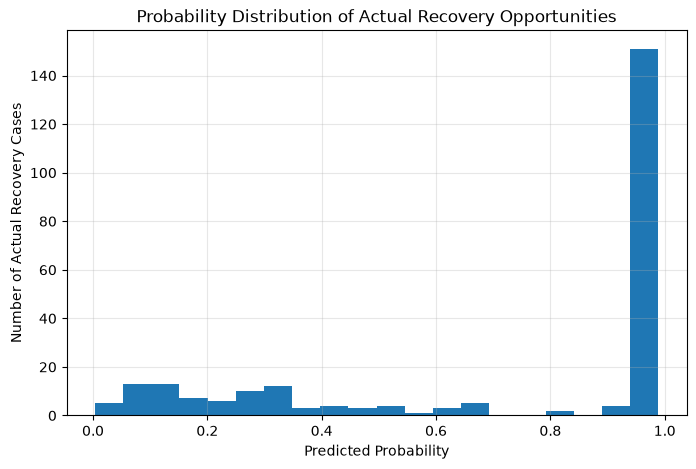

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(positive_probs, bins=20)

plt.xlabel("Predicted Probability")
plt.ylabel("Number of Actual Recovery Cases")
plt.title("Probability Distribution of Actual Recovery Opportunities")

plt.grid(alpha=0.3)
plt.show()

In [50]:
# Recall-focused XGBoost tuning

recall_param_grid = {
    "model__scale_pos_weight": [20, 40, 80],
    "model__max_depth": [6, 8],
    "model__learning_rate": [0.03, 0.05]
}

In [51]:
recall_grid_search = GridSearchCV(
    estimator=xgb_tuning,
    param_grid=recall_param_grid,
    scoring="recall",
    cv=3,
    n_jobs=1,
    verbose=1
)

recall_grid_search.fit(X_train, y_train)

print("Best Recall Parameters:")
print(recall_grid_search.best_params_)

print("\nBest CV Recall:")
print(recall_grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Recall Parameters:
{'model__learning_rate': 0.03, 'model__max_depth': 6, 'model__scale_pos_weight': 80}

Best CV Recall:
0.9786832480786813


In [52]:
recall_model = recall_grid_search.best_estimator_

y_pred_recall = recall_model.predict(X_test)
y_prob_recall = recall_model.predict_proba(X_test)[:, 1]

print("Recall-Focused XGBoost Test Results")
print("-----------------------------------")
print("Precision:", round(precision_score(y_test, y_pred_recall), 4))
print("Recall:", round(recall_score(y_test, y_pred_recall), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_recall), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_recall), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_recall), 4))

Recall-Focused XGBoost Test Results
-----------------------------------
Precision: 0.4392
Recall: 0.9837
F1-Score: 0.6073
ROC-AUC: 0.9978
PR-AUC: 0.8825
